# Mapping mouse Mixl KO to atlas

Atlas is big enough to crash the notebook so try out different partitions?

### Load packages

In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(Matrix)
    library(scran)
    library(Rtsne)
    library(BiocParallel)
    require(irlba)
    library(batchelor)
    library(stringr)
})

### I/O

In [2]:
# chimaera
mixl_data_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/mlnt/3_QC/raw_counts.rds"
mixl_genes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/2_calledCells/genes.tsv"
mixl_meta_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/mlnt/5_doubletDetection/meta.tab" # contains QC performed by Mlnt

# atlas
atlas_data_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/atlas/atlas/raw_counts.mtx"
atlas_genes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/atlas/atlas/genes.tsv"
atlas_meta_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/atlas/atlas/meta.tab"

# out folder
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"

In [3]:
# ygenes
ygenes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/ygenes.tab"

### Load data

In [2]:
# load mixl data
mixl_counts = readRDS(mixl_data_in)
mixl_genes = read.table(mixl_genes_in, stringsAsFactors = F)
mixl_meta = read.table(mixl_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
mixl_meta$cell <- paste0('chim_', mixl_meta$cell)
# annotate mixl counts
rownames(mixl_counts) = mixl_genes[,1] #ensembl
colnames(mixl_counts) = mixl_meta$cell

# load atlas data
atlas_counts = readMM(atlas_data_in) # readMM for .mtx input 
atlas_genes = read.table(atlas_genes_in, stringsAsFactors = F)
atlas_meta = read.table(atlas_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
atlas_meta$cell <- paste0('atlas_', atlas_meta$cell)
# annotate atlas counts
rownames(atlas_counts) = atlas_genes[,1] #ensembl
colnames(atlas_counts) = atlas_meta$cell

Loading required package: Matrix



#### Merge chimaera and atlas data

In [3]:
#### giving both count matrices the same genes in order to merge #######
# mixl genes
mixl_genes2 <- mixl_genes
mixl_genes2$mixl <- 1

# atlas genes
atlas_genes2 <- atlas_genes
atlas_genes2$atlas <- 1

# all genes
all_genes <- merge(mixl_genes2, atlas_genes2, by='V1', all=TRUE)

# atlas only genes
mixl_only <- all_genes[is.na(all_genes$atlas),]$V1
paste0('add to atlas: ', length(mixl_only))
atlas_only <- all_genes[is.na(all_genes$mixl),]$V1
paste0('add to mixl: ', length(atlas_only))

[1] "add to atlas: 1765"

[1] "add to mixl: 164"

In [4]:
# ensure that both count matrices have the same rows (genes)
add_mixl <- as.data.frame(matrix(0, ncol = 43825, nrow = 164)) # more elegant if nrow=length(atlas_only) & ncol=nrow(mixl_counts)?
rownames(add_mixl) <- atlas_only
colnames(add_mixl) <- colnames(mixl_counts)
add_atlas <- matrix(0, ncol = 139331, nrow = 1765) # ncol = amount of cells, nrow = genes to add
rownames(add_atlas) <- mixl_only
colnames(add_atlas) <- colnames(atlas_counts)

In [5]:
# Add genes to atlas count matrix
atlas_counts <- rbind(atlas_counts, as(as.matrix(add_atlas), "sparseMatrix"))

In [7]:
# Add genes to mixl count matrix
mixl_counts <- rbind(mixl_counts, as(as.matrix(add_mixl), "sparseMatrix"))

In [9]:
# order gene names
atlas_counts <- atlas_counts[ order(row.names(atlas_counts)), ]

In [8]:
# order gene names
mixl_counts <- mixl_counts[ order(row.names(mixl_counts)), ]

In [10]:
dim(mixl_counts)
dim(atlas_counts)

[1] 31217 43825

[1]  31217 139331

In [12]:
# create big count file
big_count <- cbind(atlas_counts, mixl_counts, deparse.level=1)

# save big_sce
saveRDS(big_count, file = paste0(out_folder,"big_count.rds"))

ERROR: Error in saveRDS(big_sce, file = paste0(out_folder, "big_sce.rds")): object 'big_sce' not found


In [16]:
###### Creating separate SCE's for atlas and mixl == NOT NEEDED!! ####### 
# create mixl SCE object
mixl_sce = SingleCellExperiment(assays = list("counts" = mixl_counts))

# Extract cells that pass all QC 
mixl_keep <- mixl_meta %>% filter(stripped == FALSE & doublet == FALSE) %>% .$cell
mixl_sce <- mixl_sce[, mixl_keep]

# create atlas SCE object
atlas_sce = SingleCellExperiment(assays = list("counts" = atlas_counts))

## save seperate SCE objects + new metadata
# mixl
saveRDS(mixl_sce, file = paste0(out_folder,"mixl_sce.rds"))
mixl_meta <- mixl_meta %>% filter(stripped == FALSE & doublet == FALSE)
write.table(mixl_meta, file = paste0(out_folder, "mixl_meta.tab"), sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

# atlas
saveRDS(atlas_sce, file = paste0(out_folder,"atlas_sce.rds"))
write.table(atlas_meta, file = paste0(out_folder, "atlas_meta.tab"), sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

In [17]:
# create SCE object from big_count
big_sce <- SingleCellExperiment(assays = list("counts" = big_count))
saveRDS(big_sce, file = paste0(out_folder,"big_sce.rds"))

#### Creating metadata

In [24]:
#### create big_metadata ####
# import metadata (fresh, in case its messed up by trial code)
mixl_meta = read.table(mixl_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
mixl_meta$cell <- paste0('chim_', mixl_meta$cell)

atlas_meta = read.table(atlas_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
atlas_meta$cell <- paste0('atlas_', atlas_meta$cell)

# add string in front of sample to differentiate atlas from chimaera
atlas_meta$sample <- paste0('atlas_',atlas_meta$sample)
mixl_meta$sample <- paste0('mixl_',mixl_meta$sample)

# put both metas in same format
atlas_original <- atlas_meta
atlas_meta <- atlas_meta %>% select('cell', 'barcode', 'sample','stage','sequencing.batch','stripped','doublet')
colnames(mixl_meta) <- c('cell', 'barcode', 'sample','stage','sequencing.batch','stripped','doublet')

mixl_meta$stage <- paste0('E',mixl_meta$stage)

# rbind
big_meta <- rbind(atlas_meta, mixl_meta)

# merge with original atlas_meta
big_meta <- merge(big_meta, atlas_original, by=c('cell', 'barcode', 'sample','stage','sequencing.batch','stripped','doublet'), all=TRUE)

# Add tdTomato information to metadata
collection <- read.csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/chim_collection_meta.csv")
collection$sample <- paste0('mixl_',collection$sample)
collection$stage <- paste0('E',collection$stage)
collection$tdTom <- sapply(strsplit(collection$Sample.Name,"_"), `[`, 3)
collection$tdTom <- str_replace(collection$tdTom, c("tdTomPOS","tdTomNEG"), c('pos', 'neg'))
collection <- collection %>% select(sample, stage, tdTom)

big_meta <- merge(big_meta, collection, by=c('sample', 'stage'), all=TRUE)

# write
write.table(big_meta, file = paste0(out_folder,"big_meta.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

In [35]:
#### gene metadata #####
genes <- data.frame(rownames(big_sce))
write.table(genes, file = paste0(out_folder,"big_genes.tab"), row.names = F, col.names = F, quote = F, sep = "\t")

#### Normalize

In [20]:
# calculate sizefactors
clusts = as.numeric(quickCluster(big_sce, method = "igraph", min.size = 100, BPPARAM = mcparam))
min.clust = min(table(clusts))/2
new_sizes = c(floor(min.clust/3), floor(min.clust/2), floor(min.clust))
big_sce = computeSumFactors(big_sce, clusters = clusts, sizes = new_sizes, max.cluster.size = 3000)
write.table(sizeFactors(big_sce), quote = F, col.names = F, row.names = F, file = paste0(out_folder,"sizefactors_big.tab"))

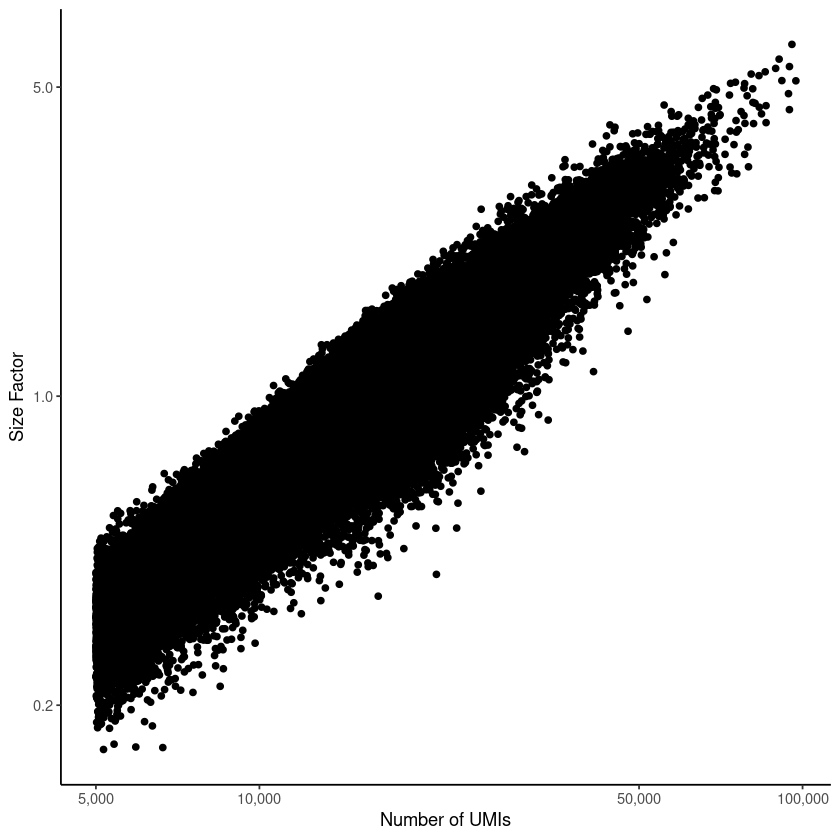

In [31]:
lib.sizes = Matrix::colSums(counts(big_sce))
ggplot(data = data.frame(X = lib.sizes, Y = sizeFactors(big_sce)),
              mapping = aes(x = X, y = Y)) +
  geom_point() +
  scale_x_log10(breaks = c(5000, 10000, 50000, 100000), labels = c("5,000", "10,000", "50,000", "100,000") ) +
  scale_y_log10(breaks = c(0.2, 1, 5)) +
  labs(x = "Number of UMIs", y = "Size Factor") + 
    theme_classic()

In [33]:
# Normalize
sfs = read.table(paste0(out_folder,"sizefactors_big.tab"), stringsAsFactors = F)[,1]
sizeFactors(big_sce) = sfs
big_sce = scater::logNormCounts(big_sce)

In [34]:
# save normalized sce
saveRDS(big_sce, file = paste0(out_folder,"big_sce_norm.rds"))

#### HVGs

In [6]:
big_sce <- readRDS(paste0(out_folder, "big_sce_norm.rds"))

In [7]:
big_sce

class: SingleCellExperiment 
dim: 31217 183156 
metadata(0):
assays(2): counts logcounts
rownames(31217): ENSMUSG00000000001 ENSMUSG00000000003 ...
  ENSMUSG00000116989 ENSMUSG00000116993
rowData names(0):
colnames(183156): atlas_cell_1 atlas_cell_2 ... chim_cell_43824
  chim_cell_43825
colData names(1): sizeFactor
reducedDimNames(0):
altExpNames(0):

In [8]:
# load genes
ychr_e = read.table(ygenes_in, stringsAsFactors = F)[,1]
genes_meta = read.table(paste0(out_folder,"big_genes.tab"), stringsAsFactors = F)
rownames(genes_meta) = genes_meta$V1

# filter sex genes (Xist + ygenes)
paste0('genes before filtering: ', length(rownames(big_sce)))
big_sce   <- big_sce[!rownames(big_sce) %in% c('ENSMUSG00000086503', ychr_e),]
paste0('genes after filtering: ', length(rownames(big_sce)))

[1] "genes before filtering: 31217"  "genes before filtering: 183156"

[1] "genes after filtering: 30483"  "genes after filtering: 183156"

In [12]:
p.val_th = 0.05 # p-value threshold

# determine top HVGs
dec <- modelGeneVar(big_sce)
hvg_p <- getTopHVGs(dec, fdr.threshold = p.val_th)
paste0('number of HVGs based on P value: ', length(hvg))
hvg_n <- getTopHVGs(dec, n = 3000)

# save
write.csv(hvg_p, file =  paste0(out_folder,"big_hvgs_p.csv"))
write.csv(hvg_n, file =  paste0(out_folder,"big_hvgs_3000.csv"))

[1] "number of HVGs based on P value: 709"

#### fastMNN 
Or melania's method if FastMNN doesn't work:
cosine normalisation, PCA, reducedMNN ( first on timepoint then on batches go from large to small)

In [2]:
# calculate uncorrected PCs + tSNE
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
big_sce <- readRDS(paste0(out_folder, "big_sce_norm.rds"))
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
hvgs = read.csv(paste0(out_folder,"big_hvgs_p.csv"))$x

In [3]:
nPC = 50
base_pca = prcomp_irlba(t(logcounts(big_sce)[rownames(big_sce) %in% hvgs,]), n = nPC)$x

In [10]:
rownames(base_pca) = colnames(big_sce)

In [11]:
head(base_pca)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,⋯,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
atlas_cell_1,-1.57622988,4.7320332,8.218824,2.1638479,-4.245321,-4.4662318,1.148581,0.7072504,-2.7013608,2.4865087,⋯,-1.1418009,-2.0523583,-0.56970311,1.3526468,0.96958832,-0.5554905,-0.7148578,0.04848312,-0.04207356,0.02167151
atlas_cell_2,-0.67179126,5.0243514,7.324364,3.3159368,-3.267815,-4.0061200,-3.065013,-1.5774588,0.4089003,0.3719696,⋯,-1.2981722,-0.3829349,0.02342504,-0.5613698,0.05019032,-0.1821853,-0.1503793,0.41796795,0.35842383,0.55912087
atlas_cell_3,14.51177272,0.4982490,3.601542,0.8550008,3.531613,4.1235503,3.778225,-3.9720705,-4.7199658,6.3998582,⋯,-0.5180171,0.6498123,0.95610842,1.0574494,0.98765268,1.7473609,-0.3986559,-0.75614370,0.73779955,-1.08003760
atlas_cell_4,-0.42306479,6.3795135,12.386622,4.0517813,0.593044,-0.6874423,3.969402,-2.7415613,-3.2568434,6.6755734,⋯,-0.7293089,0.4886722,0.30416683,1.3963647,0.21183624,2.1596027,0.7387064,1.37978784,0.47081627,-0.70834185
atlas_cell_5,6.54753661,0.7666732,6.441571,-15.6201908,-1.910150,2.3088964,4.226126,-1.3523198,-1.3335698,1.4982890,⋯,-1.6231881,0.5011321,1.19708710,2.8916208,-1.20079912,0.3175930,0.4801285,0.78091449,0.56267188,-0.70261119
atlas_cell_6,0.04004444,4.9525107,8.921723,2.0187433,-3.587386,-3.7493540,2.877362,0.4660422,-3.0064628,1.6934501,⋯,0.5463835,0.1032924,-0.39037039,0.1002486,-0.22403401,0.9060648,1.0135370,0.98835710,1.35136978,1.46791107


In [12]:
base_tsne = Rtsne(base_pca, pca = FALSE)$Y

In [ ]:
base_tsne = as.data.frame(base_tsne)
base_tsne$sample = big_meta$sample
base_tsne$state = "Uncorrected"

In [23]:
base_tsne = as.data.frame(base_tsne)
rownames(base_tsne) = colnames(big_sce)
base_tsne$cell = rownames(base_tsne)
base_tsne <- merge(base_tsne, big_meta[,c('sample', 'cell')], by='cell')
base_tsne$state = "Uncorrected"

In [24]:
head(base_tsne)

,cell,V1,V2,state,sample
,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,atlas_cell_1,4.692198,14.944067,Uncorrected,atlas_1
2,atlas_cell_10,4.067905,-12.366928,Uncorrected,atlas_1
3,atlas_cell_100,3.267019,-8.609697,Uncorrected,atlas_1
4,atlas_cell_1000,-5.462703,-1.406538,Uncorrected,atlas_3
5,atlas_cell_10000,4.710521,-17.006444,Uncorrected,atlas_8
6,atlas_cell_100000,-10.493079,-9.213691,Uncorrected,atlas_29


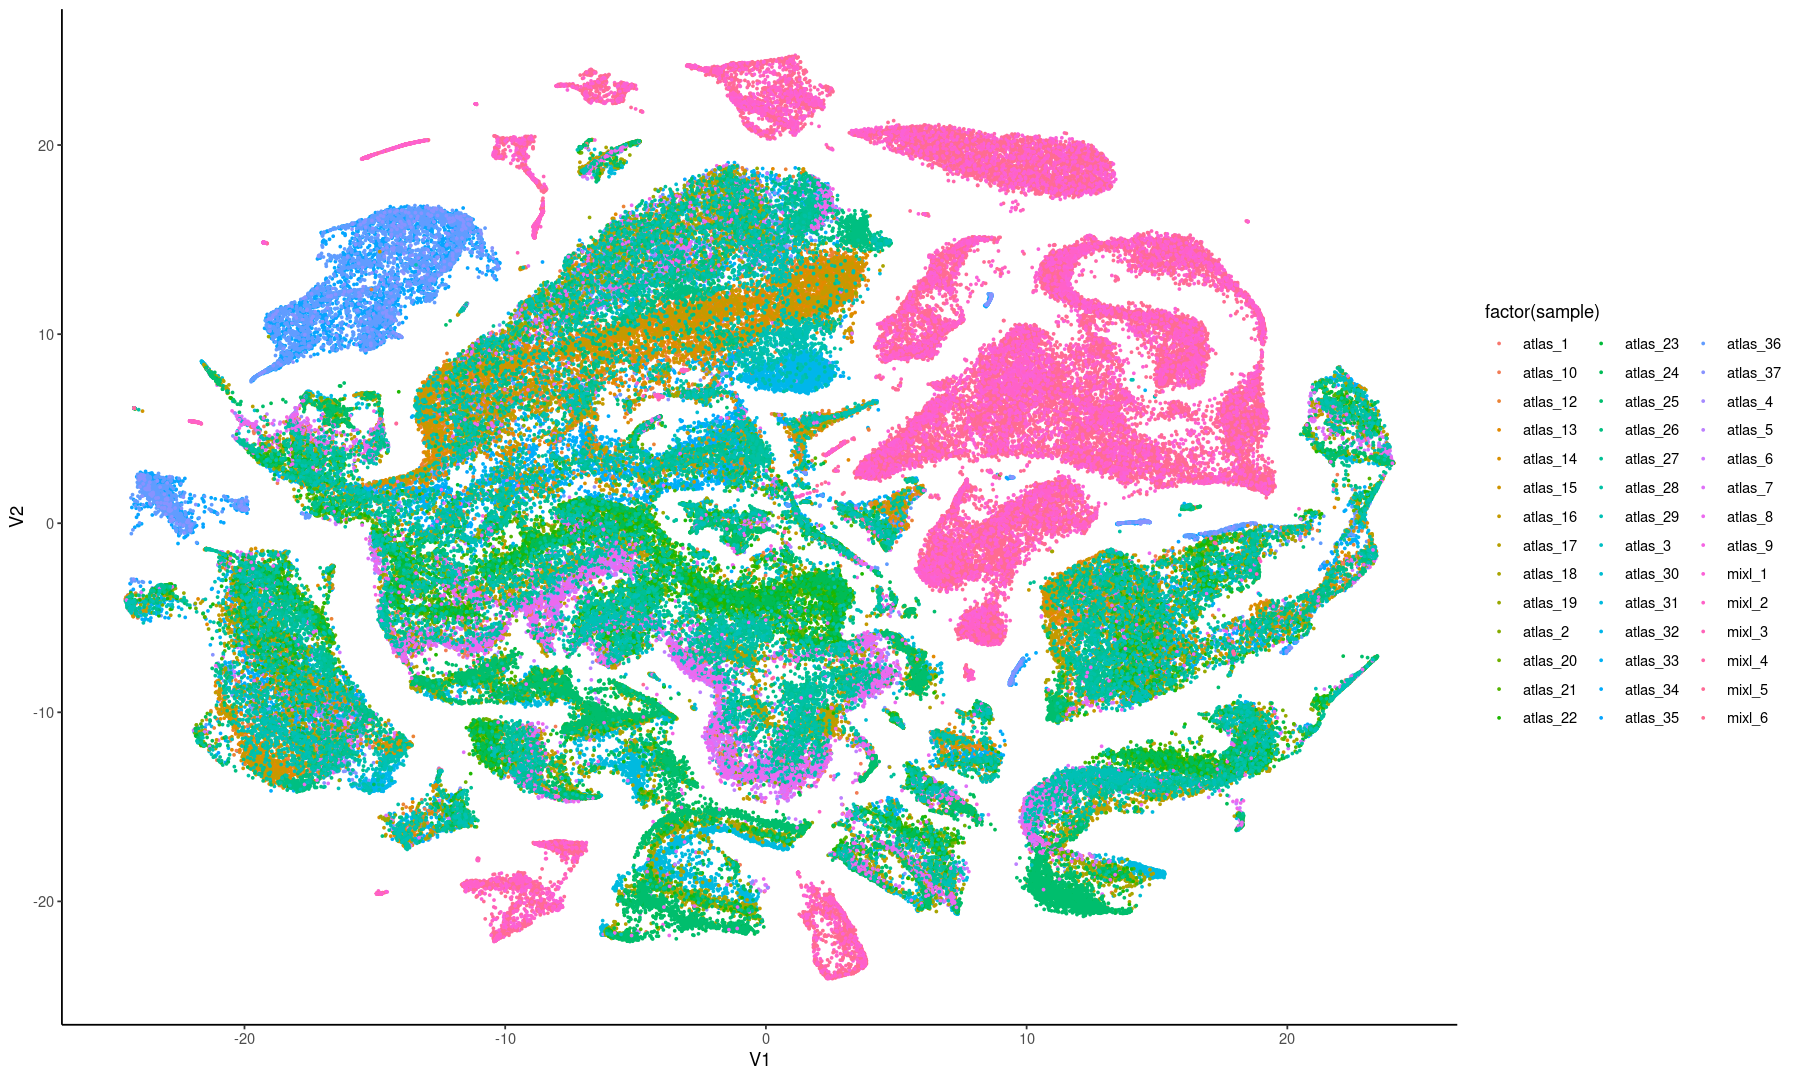

In [26]:
### Meta order not equal to big_sce order of cells so color fails!
options(repr.plot.width = 15, repr.plot.height = 9)

ggplot(base_tsne, aes(x = V1, y = V2, col = factor(sample))) +
  geom_point(size = 0.4) +
  theme_classic()

In [205]:
# get order: oldest to youngest; most cells to least cells
order_df = big_meta[!duplicated(big_meta$sample), c("stage", "sample")]
order_df$ncells = sapply(order_df$sample, function(x) sum(big_meta$sample == x))
order_df$stage = factor(order_df$stage, 
                        levels = rev(c("E8.5", 
                                   "E8.25", 
                                   "E8.0", 
                                   "E7.75", 
                                   "E7.5", 
                                   "E7.25", 
                                   "mixed_gastrulation", 
                                   "E7.0", 
                                   "E6.75", 
                                   "E6.5")))
order_df = order_df[order(order_df$stage, order_df$ncells, decreasing = TRUE),]
order_df$stage = as.character(order_df$stage)

In [29]:
timepoints = big_meta$stage
samples = big_meta$sample
timepoint_order = order_df$stage
sample_order = order_df$sample 
npc = 50

In [206]:
order_df

,stage,sample,ncells
,<chr>,<chr>,<int>
147092,E8.5,mixl_2,10357
174368,E8.5,mixl_6,8789
165723,E8.5,mixl_5,8645
139332,E8.5,mixl_1,7760
95727,E8.5,atlas_29,7569
130406,E8.5,atlas_36,4915
36865,E8.5,atlas_17,4483
157449,E8.5,mixl_3,4449
135321,E8.5,atlas_37,4011


In [32]:
unique(timepoints)

[1] "E6.5"               "E7.5"               "E6.75"             
 [4] "E7.75"              "E7.0"               "E8.0"              
 [7] "E8.5"               "mixed_gastrulation" "E7.25"             
[10] "E8.25"

In [33]:
head(base_pca)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,⋯,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
atlas_cell_1,-1.57622988,4.7320332,8.218824,2.1638479,-4.245321,-4.4662318,1.148581,0.7072504,-2.7013608,2.4865087,⋯,-1.1418009,-2.0523583,-0.56970311,1.3526468,0.96958832,-0.5554905,-0.7148578,0.04848312,-0.04207356,0.02167151
atlas_cell_2,-0.67179126,5.0243514,7.324364,3.3159368,-3.267815,-4.0061200,-3.065013,-1.5774588,0.4089003,0.3719696,⋯,-1.2981722,-0.3829349,0.02342504,-0.5613698,0.05019032,-0.1821853,-0.1503793,0.41796795,0.35842383,0.55912087
atlas_cell_3,14.51177272,0.4982490,3.601542,0.8550008,3.531613,4.1235503,3.778225,-3.9720705,-4.7199658,6.3998582,⋯,-0.5180171,0.6498123,0.95610842,1.0574494,0.98765268,1.7473609,-0.3986559,-0.75614370,0.73779955,-1.08003760
atlas_cell_4,-0.42306479,6.3795135,12.386622,4.0517813,0.593044,-0.6874423,3.969402,-2.7415613,-3.2568434,6.6755734,⋯,-0.7293089,0.4886722,0.30416683,1.3963647,0.21183624,2.1596027,0.7387064,1.37978784,0.47081627,-0.70834185
atlas_cell_5,6.54753661,0.7666732,6.441571,-15.6201908,-1.910150,2.3088964,4.226126,-1.3523198,-1.3335698,1.4982890,⋯,-1.6231881,0.5011321,1.19708710,2.8916208,-1.20079912,0.3175930,0.4801285,0.78091449,0.56267188,-0.70261119
atlas_cell_6,0.04004444,4.9525107,8.921723,2.0187433,-3.587386,-3.7493540,2.877362,0.4660422,-3.0064628,1.6934501,⋯,0.5463835,0.1032924,-0.39037039,0.1002486,-0.22403401,0.9060648,1.0135370,0.98835710,1.35136978,1.46791107


In [179]:
  #create nested list, separating PCs for each timepoint and sample
  print('creating nested list')
  pc_list = lapply(unique(timepoints), function(tp){
    sub_pc = base_pca[timepoints == tp, , drop = FALSE]
    sub_samp = samples[timepoints == tp]
    list = lapply(unique(sub_samp), function(samp){
      t(sub_pc[sub_samp == samp, , drop = FALSE])
    })
    names(list) = unique(sub_samp)
    return(list)
  })
  
  names(pc_list) = unique(timepoints)

[1] "creating nested list"


In [162]:
  #create nested list, separating PCs for each timepoint and sample
  print('creating nested list')
  pc_list = lapply(unique(timepoints), function(tp){
    sub_pc = base_pca[timepoints == tp, , drop = FALSE]
      rownames(sub_pc) <- NULL
    sub_samp = samples[timepoints == tp]
    list = lapply(unique(sub_samp), function(samp){
      sub_pc[sub_samp == samp, , drop = FALSE]
    })
    names(list) = unique(sub_samp)
    return(list)
  })
  
  names(pc_list) = unique(timepoints)

[1] "creating nested list"


In [168]:
pc_list[[3]][[2]]

ERROR: Error in pc_list[[3]][[2]]: subscript out of bounds


In [185]:
  #create nested list, separating PCs for each timepoint and sample
  print('creating nested list')
  pc_list = lapply(unique(timepoints), function(tp){
    sub_pc = base_pca[timepoints == tp, , drop = FALSE]
      rownames(sub_pc) <- NULL
    sub_samp = samples[timepoints == tp]
    list = lapply(unique(sub_samp), function(samp){
      sub_pc[sub_samp == samp, , drop = FALSE]
    })
    names(list) = unique(sub_samp)
    return(list)
  })
  
  names(pc_list) = unique(timepoints)

[1] 50

In [199]:
test <- matrix(x)

In [203]:
test <- list()

In [204]:
head(big_meta)

,cell,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,⋯,endo_gephiX,endo_gephiY,endo_trajectoryName,endo_trajectoryDPT,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster,tdTom,weight
,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<int>,⋯,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>
1,atlas_cell_1,atlas_1,E6.5,AAAGGCCTCCACAA,1,FALSE,FALSE,TS9,0.04311420,2,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,1
2,atlas_cell_2,atlas_1,E6.5,AACAAACTCGCCTT,1,FALSE,FALSE,TS9,1.12971326,12,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,2
3,atlas_cell_3,atlas_1,E6.5,AACAATACCCGTAA,1,TRUE,FALSE,TS9,0.00000000,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,3
4,atlas_cell_4,atlas_1,E6.5,AACACTCTCATTCT,1,TRUE,FALSE,TS9,0.08468852,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,4
5,atlas_cell_5,atlas_1,E6.5,AACAGAGAATCAGC,1,FALSE,FALSE,TS9,0.11212055,3,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,5
6,atlas_cell_6,atlas_1,E6.5,AACATATGAATCGC,1,FALSE,FALSE,TS9,1.25470878,1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,6


In [217]:
mat_temp = logcounts(big_sce)
mat = mat_temp[hvgs,]

In [219]:
test[[1]] <- mat[,big_meta$stage == 'E6.5']
test[[2]] <- mat[,big_meta$stage == 'E6.75']

In [227]:
comb <- list()
for(i in unique(big_meta$stage)){
    comb[[i]] <- mat[, big_meta$stage == i]
}

In [232]:
length(comb)

[1] 10

In [231]:
comb[[4]]

   [[ suppressing 33 column names ‘atlas_cell_7625’, ‘atlas_cell_7626’, ‘atlas_cell_7627’ ... ]]



709 x 17720 sparse Matrix of class "dgCMatrix"
                                                                          
ENSMUSG00000052217 .        6.025917 2.632531 .         .         .       
ENSMUSG00000055609 .        .        .        .         .         .       
ENSMUSG00000069919 .        .        .        .         .         .       
ENSMUSG00000010760 4.611246 1.101459 1.450860 1.5221066 4.1615403 1.115110
ENSMUSG00000052187 .        .        .        .         .         .       
ENSMUSG00000002985 3.604368 2.481005 3.273299 1.9290910 3.9412319 2.169394
ENSMUSG00000061808 .        1.101459 .        0.9531166 .         .       
ENSMUSG00000032083 1.081510 .        3.273299 0.9531166 .         1.736488
ENSMUSG00000095180 5.108001 1.101459 2.632531 .         5.5941883 .       
ENSMUSG00000024990 2.120600 1.101459 1.450860 .         0.8834523 1.115110
ENSMUSG00000051855 .        .        1.450860 0.9531166 0.8834523 .       
ENSMUSG00000069917 .        .        .        .      

In [212]:
test2 <- big_sce[,big_meta$stage == 'E6.75']

In [221]:
test[[1]]

   [[ suppressing 33 column names ‘atlas_cell_1’, ‘atlas_cell_2’, ‘atlas_cell_3’ ... ]]



709 x 3697 sparse Matrix of class "dgCMatrix"
                                                                         
ENSMUSG00000052217 .        .        .        .        .        .        
ENSMUSG00000055609 .        .        .        .        .        .        
ENSMUSG00000069919 .        .        .        .        .        .        
ENSMUSG00000010760 .        2.103654 .        .        1.023749 .        
ENSMUSG00000052187 .        .        .        .        .        .        
ENSMUSG00000002985 .        2.925227 4.412639 1.299089 3.041307 2.0528653
ENSMUSG00000061808 .        .        3.753926 .        .        .        
ENSMUSG00000032083 .        .        3.911920 .        .        .        
ENSMUSG00000095180 .        .        3.576478 .        5.505491 .        
ENSMUSG00000024990 .        .        3.374101 .        .        .        
ENSMUSG00000051855 .        .        2.506939 .        1.616541 1.3643742
ENSMUSG00000069917 .        .        .        .        .        . 

In [220]:
cosineNorm(test[[1]])

   [[ suppressing 33 column names ‘atlas_cell_1’, ‘atlas_cell_2’, ‘atlas_cell_3’ ... ]]



709 x 3697 sparse Matrix of class "dgCMatrix"
                                                                         
ENSMUSG00000052217 .          .          .          .          .         
ENSMUSG00000055609 .          .          .          .          .         
ENSMUSG00000069919 .          .          .          .          .         
ENSMUSG00000010760 .          0.05097589 .          .          0.02732174
ENSMUSG00000052187 .          .          .          .          .         
ENSMUSG00000002985 .          0.07088430 0.10642891 0.03395709 0.08116620
ENSMUSG00000061808 .          .          0.09054136 .          .         
ENSMUSG00000032083 .          .          0.09435203 .          .         
ENSMUSG00000095180 .          .          0.08626146 .          0.14693016
ENSMUSG00000024990 .          .          0.08138032 .          .         
ENSMUSG00000051855 .          .          0.06046514 .          0.04314215
ENSMUSG00000069917 .          .          .          .          .  

In [202]:
big_sce

class: SingleCellExperiment 
dim: 31217 183156 
metadata(0):
assays(2): counts logcounts
rownames(31217): ENSMUSG00000000001 ENSMUSG00000000003 ...
  ENSMUSG00000116989 ENSMUSG00000116993
rowData names(0):
colnames(183156): atlas_cell_1 atlas_cell_2 ... chim_cell_43824
  chim_cell_43825
colData names(1): sizeFactor
reducedDimNames(0):
altExpNames(0):

#### Map

#### Integration